In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

data = {
    "patient_id": range(1, n+1),
    "age": np.random.choice(range(18,90), n),
    "gender": np.random.choice(["Male", "Female"], n, p=[0.65, 0.35]),  # gender bias
    "region": np.random.choice(["Urban", "Rural"], n, p=[0.7, 0.3]),
    "bmi": np.round(np.random.normal(28, 6, n),1),
    "glucose": np.round(np.random.normal(130, 30, n),1),
    "diagnosis_year": np.random.choice(range(2019,2025), n),
    "outcome": np.random.choice([0,1], n, p=[0.75,0.25])
}

df = pd.DataFrame(data)

# introduce missingness (data quality issue)
df.loc[df.sample(frac=0.08).index, "bmi"] = np.nan
df.loc[df.sample(frac=0.05).index, "age"] = np.nan

df.head()



,patient_id,age,gender,region,bmi,glucose,diagnosis_year,outcome
0,1,69.0,Female,Rural,19.5,137.9,2022,0
1,2,NaN,Male,Urban,29.3,120.2,2023,1
2,3,89.0,Male,Urban,22.8,156.4,2024,1
3,4,78.0,Male,Urban,21.8,151.1,2022,0
4,5,38.0,Male,Urban,25.4,156.2,2019,1


In [4]:
df.head()
df.info()
df.isnull().mean() * 100



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      1000 non-null   int64  
 1   age             950 non-null    float64
 2   gender          1000 non-null   object 
 3   region          1000 non-null   object 
 4   bmi             920 non-null    float64
 5   glucose         1000 non-null   float64
 6   diagnosis_year  1000 non-null   int64  
 7   outcome         1000 non-null   int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 62.6+ KB


,0
patient_id,0.0
age,5.0
gender,0.0
region,0.0
bmi,8.0
glucose,0.0
diagnosis_year,0.0
outcome,0.0


In [5]:
#transform
#bias detection

gender_bias = df["gender"].value_counts(normalize=True) * 100
gender_bias


,proportion
gender,
Male,66.2
Female,33.8


<Axes: >

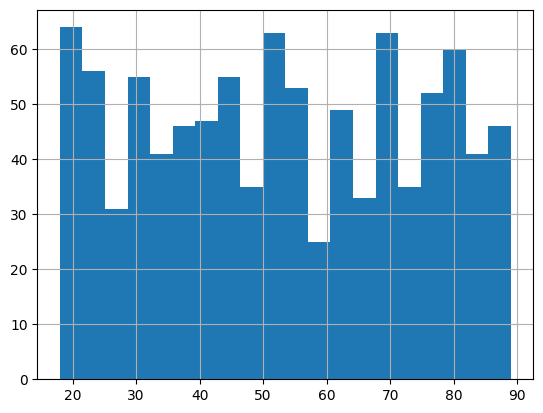

In [6]:
#age  distribution bias
df["age"].dropna().hist(bins=20)


In [8]:
#BMI drift over time
bmi_drift = df.groupby("diagnosis_year")["bmi"].mean()
bmi_drift
bmi_drift = df.groupby("diagnosis_year")["bmi"].mean()
bmi_drift


,bmi
diagnosis_year,
2019,28.411921
2020,27.731746
2021,28.207639
2022,28.018045
2023,28.081481
2024,28.492908


In [9]:
#ethical cleaning
df_clean = df.copy()

df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())
df_clean["bmi"] = df_clean["bmi"].fillna(df_clean["bmi"].median())


In [10]:
#bias and quality report
report = {
    "gender_distribution_percent": gender_bias.to_dict(),
    "missing_values_percent": (df.isnull().mean()*100).to_dict(),
    "bmi_drift_by_year": bmi_drift.to_dict()
}

report


{'gender_distribution_percent': {'Male': 66.2, 'Female': 33.800000000000004},
 'missing_values_percent': {'patient_id': 0.0,
  'age': 5.0,
  'gender': 0.0,
  'region': 0.0,
  'bmi': 8.0,
  'glucose': 0.0,
  'diagnosis_year': 0.0,
  'outcome': 0.0},
 'bmi_drift_by_year': {2019: 28.411920529801325,
  2020: 27.731746031746034,
  2021: 28.20763888888889,
  2022: 28.018045112781955,
  2023: 28.08148148148148,
  2024: 28.49290780141844}}

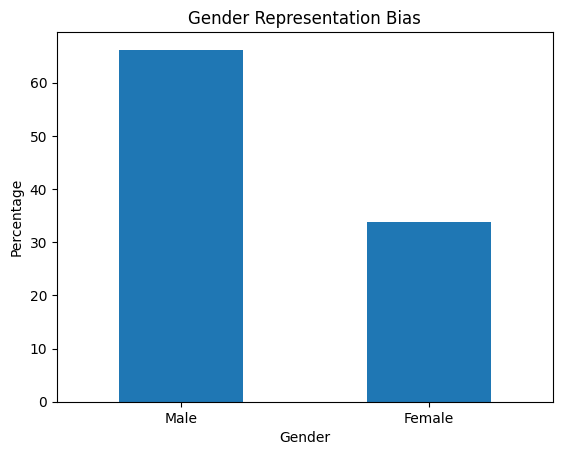

In [11]:
#gender bias visualization
import matplotlib.pyplot as plt

gender_bias.plot(
    kind="bar",
    title="Gender Representation Bias",
    ylabel="Percentage",
    xlabel="Gender",
    rot=0
)
plt.show()


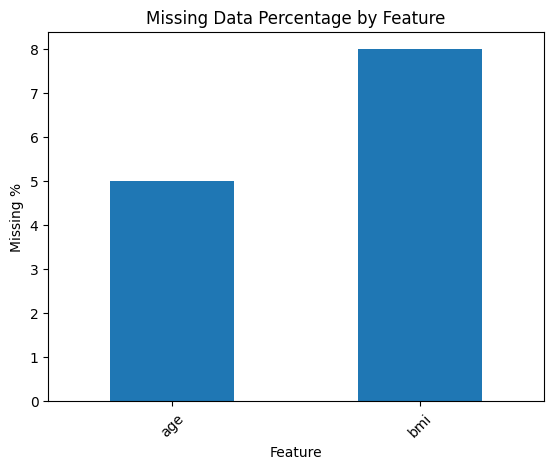

In [12]:
#age distribution
missing_vals = df.isnull().mean() * 100
missing_vals = missing_vals[missing_vals > 0]

missing_vals.plot(
    kind="bar",
    title="Missing Data Percentage by Feature",
    ylabel="Missing %",
    xlabel="Feature",
    rot=45
)
plt.show()


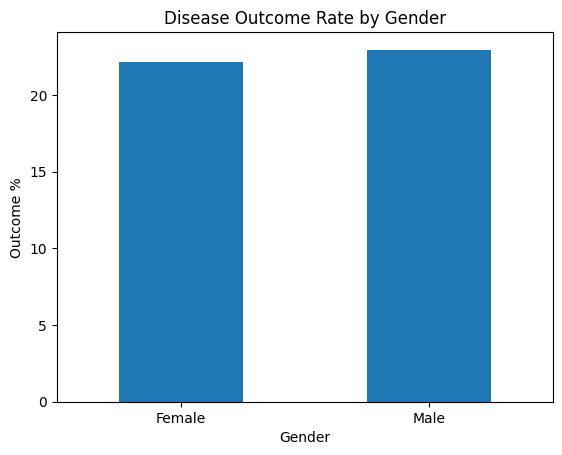

In [13]:
#outcome vs gender bias
outcome_gender = df.groupby("gender")["outcome"].mean() * 100

outcome_gender.plot(
    kind="bar",
    title="Disease Outcome Rate by Gender",
    ylabel="Outcome %",
    xlabel="Gender",
    rot=0
)
plt.show()


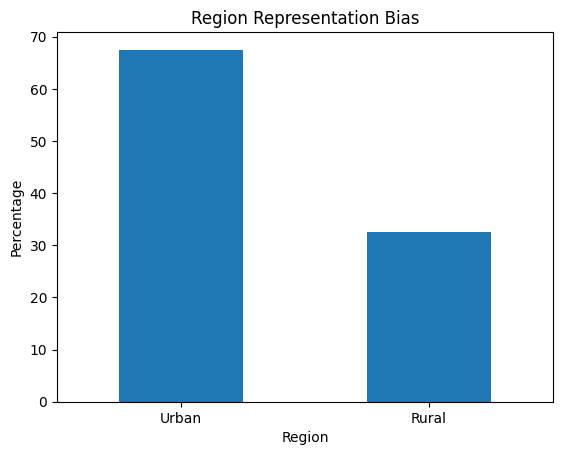

In [14]:
#region based bias
region_dist = df["region"].value_counts(normalize=True) * 100

region_dist.plot(
    kind="bar",
    title="Region Representation Bias",
    ylabel="Percentage",
    xlabel="Region",
    rot=0
)
plt.show()
